In [2]:
import pandas as pd

df = pd.read_csv("http://114.207.245.181:13000/csv/ecg.csv", header=None)
df

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,1.0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4993,0.608558,-0.335651,-0.990948,-1.784153,-2.626145,-2.957065,-2.931897,-2.664816,-2.090137,-1.461841,...,1.757705,2.291923,2.704595,2.451519,2.017396,1.704358,1.688542,1.629593,1.342651,0.0
4994,-2.060402,-2.860116,-3.405074,-3.748719,-3.513561,-3.006545,-2.234850,-1.593270,-1.075279,-0.976047,...,1.388947,2.079675,2.433375,2.159484,1.819747,1.534767,1.696818,1.483832,1.047612,0.0
4995,-1.122969,-2.252925,-2.867628,-3.358605,-3.167849,-2.638360,-1.664162,-0.935655,-0.866953,-0.645363,...,-0.472419,-1.310147,-2.029521,-3.221294,-4.176790,-4.009720,-2.874136,-2.008369,-1.808334,0.0
4996,-0.547705,-1.889545,-2.839779,-3.457912,-3.929149,-3.966026,-3.492560,-2.695270,-1.849691,-1.374321,...,1.258419,1.907530,2.280888,1.895242,1.437702,1.193433,1.261335,1.150449,0.804932,0.0


In [3]:
df.columns

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140],
      dtype='int64', length=141)

In [6]:
# 140번째가 label
df[[140]]

,140
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
4993,0.0
4994,0.0
4995,0.0
4996,0.0


In [7]:
data = df[df.columns[:-1]].values
label = df[140].values

data.shape, label.shape

((4998, 140), (4998,))

In [8]:
# 훈련, 테스트 나누기
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(data, label, test_size=0.2, random_state=123)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((3998, 140), (1000, 140), (3998,), (1000,))

In [9]:
# minmax scaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train_scaled.shape, x_test_scaled.shape, y_train.shape, y_test.shape

((3998, 140), (1000, 140), (3998,), (1000,))

In [11]:
# y_train 에서 0이면 false 1이면 true로 변경
y_train_label = y_train.astype(bool)
y_train_label[:3]

array([ True, False, False])

In [12]:
x_train_normal    = x_train_scaled[y_train_label]   # true 인것만 추출
x_train_anomalous = x_train_scaled[~y_train_label]  # false 인것만 추출

x_train_normal.shape, x_train_anomalous.shape

((2323, 140), (1675, 140))

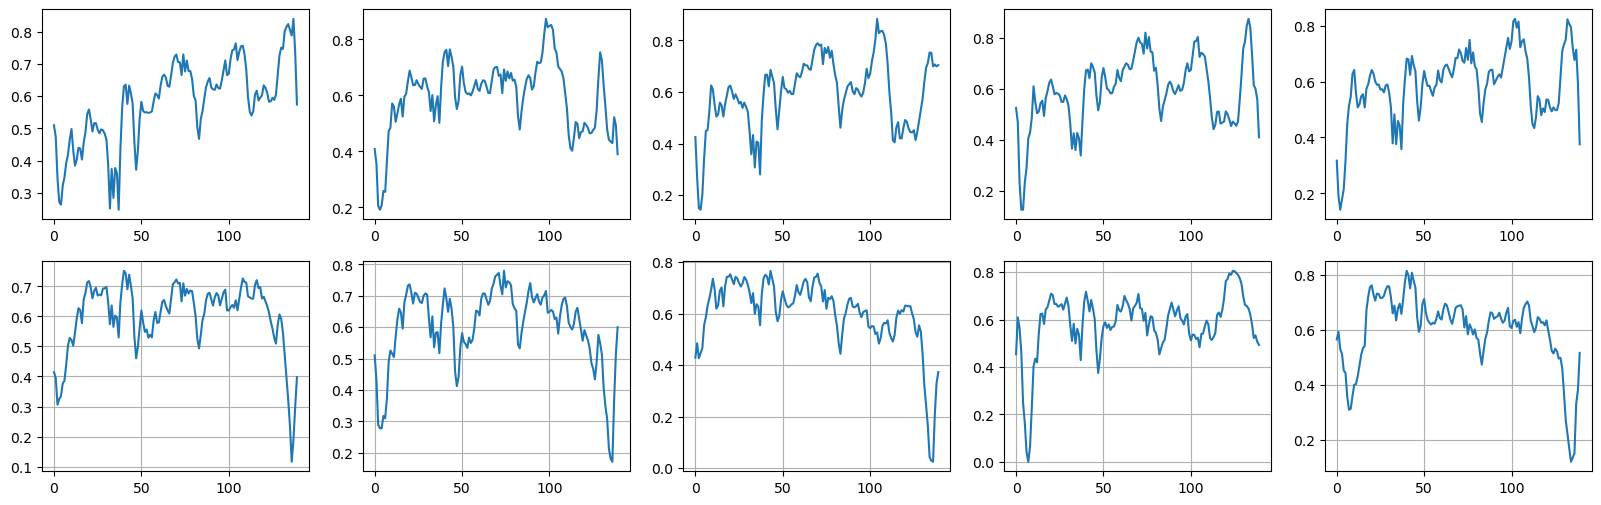

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(20, 6))
for i in range(5):
    plt.subplot(2, 5, (i+1))
    plt.plot(np.arange(140), x_train_normal[i])

    plt.subplot(2, 5, (i+1+5))
    plt.plot(np.arange(140), x_train_anomalous[i])
    plt.grid()

In [16]:
y_test_label = y_test.astype(bool)

x_test_normal    = x_test_scaled[y_test_label]   # true 인것만 추출
x_test_anomalous = x_test_scaled[~y_test_label]  # false 인것만 추출

x_train_normal.shape, x_train_anomalous.shape, x_test_normal.shape, x_test_anomalous.shape

((2323, 140), (1675, 140), (596, 140), (404, 140))

In [17]:
import tensorflow as tf
from tensorflow.keras import layers

encoder_input = layers.Input(shape=(140,))
x = layers.Dense(units=32, activation="elu")(encoder_input)
x = layers.Dense(units=16, activation="elu")(x)
encoder_output = layers.Dense(units=8, activation="elu")(x)

encoder = tf.keras.models.Model(encoder_input, encoder_output)
encoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 140)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,176 (20.22 KB)

 Trainable params: 5,176 (20.22 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
decoder_input = layers.Input(shape=(8,))
x = layers.Dense(units=16, activation="elu")(decoder_input)
x = layers.Dense(units=32, activation="elu")(x)
decoder_output = layers.Dense(units=140, activation="sigmoid")(x)

decoder = tf.keras.models.Model(decoder_input, decoder_output)
decoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 140)            │         4,620 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,308 (20.73 KB)

 Trainable params: 5,308 (20.73 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
auto_input = layers.Input(shape=(140,))
encoded = encoder(auto_input)
decoded = decoder(encoded)

autoencoder = tf.keras.models.Model(auto_input, decoded)
autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 140)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 8)              │         5,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ (None, 140)            │         5,308 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,484 (40.95 KB)

 Trainable params: 10,484 (40.95 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
autoencoder.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [25]:
autoencoder.fit(x_train_normal, x_train_normal, epochs=100, validation_data=(x_test_normal, x_test_normal))

Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0112 - mae: 0.0753 - val_loss: 0.0061 - val_mae: 0.0519
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0050 - mae: 0.0479 - val_loss: 0.0052 - val_mae: 0.0483
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0040 - mae: 0.0424 - val_loss: 0.0039 - val_mae: 0.0416
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0033 - mae: 0.0383 - val_loss: 0.0034 - val_mae: 0.0384
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0028 - mae: 0.0347 - val_loss: 0.0028 - val_mae: 0.0345
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0023 - mae: 0.0318 - val_loss: 0.0025 - val_mae: 0.0323
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0021 - mae: 0.0302 - val_loss: 0.0023 - val_mae: 0.0309
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0019 - mae: 0.0291 - val_loss: 0.0022 - val_mae: 0.0303
Epoch 9/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.001

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


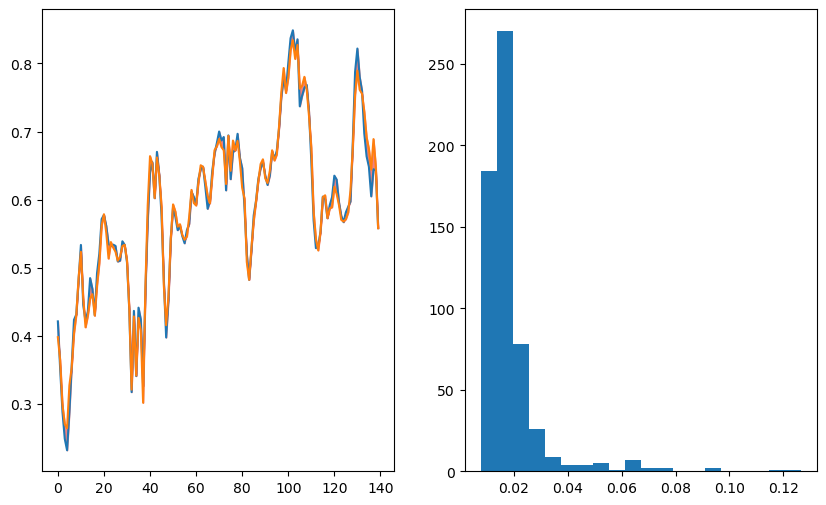

In [38]:
# 정상 데이터
decoded_data = autoencoder.predict(x_test_normal)

plt.figure(figsize=(10, 6))

plt.subplot(1,2,1)
plt.plot(x_test_normal[0])
plt.plot(decoded_data[0])
plt.fill_between(np.arange(140), decoded_data[0], x_test_normal[0], color='lightcoral')\

train_loss = tf.keras.losses.mae(decoded_data, x_test_normal)
plt.subplot(1,2,2)
plt.hist(train_loss, bins=20)

plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


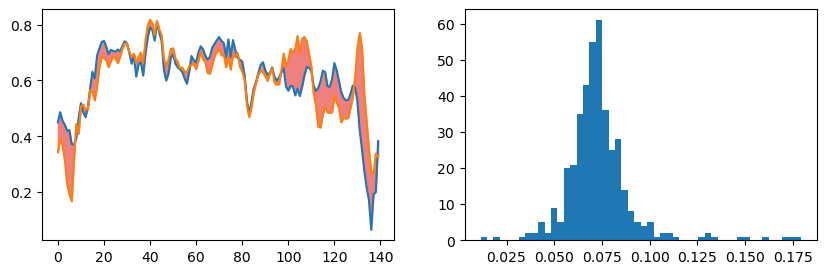

In [37]:
# 비정상 데이터
decoded_data = autoencoder.predict(x_test_anomalous)

plt.figure(figsize=(10, 3))

plt.subplot(1,2,1)
plt.plot(x_test_anomalous[0])
plt.plot(decoded_data[0])
plt.fill_between(np.arange(140), decoded_data[0], x_test_anomalous[0], color='lightcoral')

train_loss = tf.keras.losses.mae(decoded_data, x_test_anomalous)
plt.subplot(1,2,2)
plt.hist(train_loss, bins=50)

plt.show()